# Goal
Merge all the parameters for the model

# Var

In [1]:
work_dir = '../../..'

# Init

In [2]:
suppressMessages({library(tidyverse)
library(Biostrings)
library(ggmsa)
})
suppressWarnings(library(LeyLabRMisc))

In [3]:
## Load feature engineering helper functions
source('./feature_engineering_helpers.R')

In [4]:
df.dims(2)

# Load

In [5]:
# current information
# taxonomy + exp. phenotype table

# ready paramateres - alignment based, foldseek
flaB_like_path =file.path(work_dir, 'out/annotation/functional/diamond_blastp/FlaB_like_curated_2025_01_30_2569.fasta')
fliC_like_path =file.path(work_dir, 'out/annotation/functional/diamond_blastp/FliC_like_curated_2025_01_30_2569.fasta')
flaB_foldseek_path = file.path(work_dir, 'out/annotation/functional/structure_aware/foldseek/masked_foldseek_31-01-25.m8')

# for creating table with biophesical properties of a.a. involved in binding for FliC
fliC_fasta_path = file.path(work_dir, 'data/ref/Flagellins/Q549S3.fasta')
fliC_binding_res_path = file.path(work_dir, 'data/ref/Flagellins/aa-involved-in-binding-FliC.txt')
msa_path = file.path(work_dir, 'out/alignment/mafft_msa_curated_fla_added_seq_30-01-25.fasta')
all_fasta_path = file.path(work_dir, 'data/ref/Flagellins/Curated_Formatted_fla_with_all_exp_idb.healty.fasta')

properties_aa_path = file.path(work_dir, 'data/annotation/functional/alignment_based/a_a_properties_v4_W_corrected.txt')
exp_features_path = file.path(work_dir, 'data/ref/Flagellins/flagellin_screen_classification.txt')

In [6]:
# output file
output_file = file.path(work_dir, 'out/annotation/functional/parameters_for_model_curated_2569-31-01-25.tsv')

# Main

## I. Translate positions of a.a. involved in binding from FliC to all flagellins and get charge and hydrophobic properties

### 1. Read files

In [7]:
fliC_fasta = readAAStringSet(fliC_fasta_path)
fliC_fasta

AAStringSet object of length 1:
    width seq                                               names               
[1]   506 MAQVINTNSLSLLTQNNLNKSQS...QQAGTSVLAQANQVPQNVLSLLR Q549S3_StFliC

In [8]:
positions_aa <- read_table(fliC_binding_res_path)
positions_aa


── Column specification ────────────────────────────────────────────────────────
cols(
  Residue = col_character(),
  Position = col_double()
)



Residue,Position
<chr>,<dbl>
E,78
⋮,⋮
R/K,478


In [9]:
msa <- readAAMultipleAlignment(msa_path, format = 'fasta')
data(BLOSUM62)
msa

Warning message in data(BLOSUM62):
“data set ‘BLOSUM62’ not found”


AAMultipleAlignment with 2569 rows and 4662 columns
        aln                                                 names               
   [1] ------------------------...------------------------ SAE38355_1
   [2] ------------------------...------------------------ SAB91600_1
   [3] ------------------------...------------------------ SAD89708_1
   [4] ------------------------...------------------------ KLQ36000_1
   [5] ------------------------...------------------------ WP_096198834_1
   [6] ------------------------...------------------------ CCP03555_1
   [7] ------------------------...------------------------ SAC56677_1
   [8] ------------------------...------------------------ WP_103883436_1
   [9] ------------------------...------------------------ WP_059294697_1
   ... ...
[2561] ------------------------...------------------------ DAA91423_1
[2562] ------------------------...Q----------------------- DAB02860_1
[2563] ------------------------...Q----------------------- DAB09406_1
[256

In [10]:
all_fla <- readAAStringSet(all_fasta_path, format = 'fasta')
all_fla


AAStringSet object of length 2569:
       width seq                                            names               
   [1]   358 MAQVINTNSLSLITQNNINKNQ...GNSVLSKANQVPQQVLSLLQG SAE38355_1
   [2]   670 MAQVINTNSLSLITQNNINKNQ...GNSVLAKANQVPQQVLSLLQG KQJ28205_1
   [3]   557 MAQVINTNSLSLITQNNINKNQ...GNSVLAKANQVPQQVLSLLQG ORT39682_1
   [4]   585 MAQVINTNSLSLITQNNINKNQ...GNSVLAKANQVPQQVLSLLQG WP_000079688_1
   [5]   506 MAQVINTNSLSLLTQNNLNKSQ...AGTSVLAQANQTTQNVLSLLR WP_108085430_1
   ...   ... ...
[2565]   376 MAINVNTNVSAMTAQRYLNGAA...ASTSVLAQAKQSPSAALSLLG P0C6C4_VcFlaB
[2566]   393 MRINYNASAVVTNKTLNRNDEL...AGISMLAQANERPQQVLQLLQ WP_022783963_1
[2567]   352 MTQERLSTGKKVNSAIDNPSSY...QLAINSLSLASQAAQSVLSLF CDB53741_1
[2568]   379 MSDISLTASMRSNLLSLQNTQS...QLAINSLSLASQAAQSVLKLF PWM92011_1
[2569]   376 MADISLTASMRSNLLSLQNTQS...QLGVNSLSLASQAAQAVLKLF PWM92012_1

### 2. Check that a.a. in txt is the same as in fasta 

In [11]:
protein_sequence <- as.character(fliC_fasta[[1]])
protein_sequence

[1] "MAQVINTNSLSLLTQNNLNKSQSALGTAIERLSSGLRINSAKDDAAGQAIANRFTANIKGLTQASRNANDGISIAQTTEGALNEINNNLQRVRELAVQSANSTNSQSDLDSIQAEITQRLNEIDRVSGQTQFNGVKVLAQDNTLTIQVGANDGETIDIDLKQINSQTLGLDSLNVQKAYDVKDTAVTTKAYANNGTTLDVSGLDDAAIKAATGGTNGTASVTGGAVKFDADNNKYFVTIGGFTGADAAKNGDYEVNVATDGTVTLAAGATKTTMPAGATTKTEVQELKDTPAVVSADAKNALIAGGVDATDANGAELVKMSYTDKNGKTIEGGYALKAGDKYYAADYDEATGAIKAKTTSYTAADGTTKTAANQLGGVDGKTEVVTIDGKTYNASKAAGHDFKAQPELAEAAAKTTENPLQKIDAALAQVDALRSDLGAVQNRFNSAITNLGNTVNNLSEARSRIEDSDYATEVSNMSRAQILQQAGTSVLAQANQVPQNVLSLLR"

In [12]:
residue_positions <- data.frame(
  Residue_fasta = unlist(strsplit(protein_sequence, "")),  
  Position_fasta = seq_along(unlist(strsplit(protein_sequence, ""))) - 1) # the indexation starts from 0

check_the_positions <- right_join(residue_positions, positions_aa, by = c("Position_fasta" = "Position")) %>% 
                        mutate(Status = ifelse(Residue==Residue_fasta, "Match", "Mismatch")) %>%
                        group_by(Status) %>% summarise(n = n())

check_the_positions

# everything seems to be fine, 1 mismatch due to pos 478	R/K	Mismatch (R in E. coli)

Status,n
<chr>,<int>
Match,21
Mismatch,1


### 3. Translate positions on the alignment and get positions for other sequences 

In [13]:
# Extract Protein_IDs (sequence names)
protein_ids <- names(msa@unmasked)

target_protein_id <- "Q549S3_StFliC" 

# Find the index of StFliC
protein_index <- which(protein_ids == target_protein_id)

# Extract the sequence as a character string
if (length(protein_index) > 0) {
    target_sequence <- as.character(msa@unmasked[protein_index])
    cat("Sequence for", target_protein_id, ":\n", target_sequence, "\n")
} else {
    cat("Protein_ID not found:", target_protein_id, "\n")
}

protein_index


Sequence for Q549S3_StFliC :
 ---------------------------------------------------------------------------------------------------------------------------------MA-------------------------------------QV---------------------------------------------------------------------------------------------------------------------------I---------NT-NSLSLLTQNNLNKSQSAL--GTAIERLS--SGLRINSAKDDAAGQAIANRFTANIKG-----LTQASRNANDGISIAQTTEGALNEINNNLQRVRELAVQSAN-S----TN-S-Q--------------------S-DLDSIQAEITQRLNEIDRVSGQTQFNGVKVL-----------A-Q--D-----------------N--------T--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

[1] 704

In [14]:
# positions_data should have two columns: Residue and Position

# Use the reference protein to map the positions
reference_sequence <- as.character(msa@unmasked[704]) 
reference_sequence <- unname(reference_sequence)
reference_sequence <- unlist(strsplit(reference_sequence, ""))


# Remove gaps ('-') from the sequence
reference_no_gaps <-  reference_sequence[reference_sequence != "-"]


In [15]:
# Map positions from the protein sequence to MSA
position_mapping <- which(reference_sequence != "-")  # MSA indices for non-gap positions

In [16]:
# Translate positions in the protein sequence to MSA indices
msa_positions <- position_mapping[positions_aa$Position + 1]  # Adjust for 0-based indexing

In [17]:
msa_positions

[1]  387  397  398  399  403  404  406  409  411  417  419  450  453  454 4333
[16] 4355 4356 4361 4362 4363 4365 4504

In [18]:
# Extract residues at these positions for all sequences in the MSA
msa_residues <- data.frame(
    Protein_ID = names(msa@unmasked),  # Sequence identifiers from the MSA
    t(sapply(as.character(msa@unmasked), function(seq) {
        seq_split <- unlist(strsplit(seq, ""))
        seq_split[msa_positions]  # Extract residues at specified MSA positions
    }))
)
# rename columns for clarity
colnames(msa_residues)[-1] <- paste0(positions_aa$Residue, positions_aa$Position)
rownames(msa_residues) <- NULL

In [19]:
msa_residues

Protein_ID,E78,L88,Q89,R90,L94,A95,Q97,N100,S101,⋯,T116,Q117,I422,V439,Q440,S445,A446,I447,N449,R/K478
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,E,L,Q,R,L,T,Q,T,G,⋯,K,S,L,I,Q,S,A,V,N,K
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92012_1,N,V,Q,Q,V,A,Q,D,E,⋯,-,-,V,N,Y,N,R,E,F,A


In [20]:
# Save the results
msa_residues_out <- file.path(work_dir, 'out/annotation/functional/msa_2569_positions-aa-involved-in-binding-FliC-31-01-25.csv')
write.csv(msa_residues, msa_residues_out, row.names = FALSE, quote = FALSE)


cat("Residues extracted. Results saved to:", output_file, "\n")

Residues extracted. Results saved to: ../../../out/annotation/functional/parameters_for_model_curated_2569-31-01-25.tsv 


### 4. Give properties for the amino acids in msa_residues

In [21]:
df.dims(20)
properties_aa = read_table(properties_aa_path)
properties_aa


── Column specification ────────────────────────────────────────────────────────
cols(
  A.afull = col_character(),
  abbr = col_character(),
  letter = col_character(),
  Hydrophobicity = col_character(),
  Charge = col_character(),
  Polarity = col_character(),
  R_or_K = col_double()
)



A.afull,abbr,letter,Hydrophobicity,Charge,Polarity,R_or_K
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
Alanine,Ala,A,hydrophobic,neutral,nonpolar,0
Arginine,Arg,R,hydrophilic,positive,polar,1
Asparagine,Asn,N,hydrophilic,neutral,polar,0
Asparticacid,Asp,D,hydrophilic,negative,polar,0
Cysteine,Cys,C,hydrophobic,neutral,nonpolar,0
Glutamine,Gln,Q,hydrophilic,neutral,polar,0
Glutamicacid,Glu,E,hydrophilic,negative,polar,0
Glycine,Gly,G,neutral,neutral,nonpolar,0
Histidine,His,H,neutral,positive,polar,0


In [22]:
df.dims(5)
properties_aa <- properties_aa %>%
    mutate(
        Hydrophobicity = case_when(
            Hydrophobicity == 'hydrophobic' ~ '-1',
            Hydrophobicity == 'hydrophilic' ~ '1',
            Hydrophobicity == 'neutral' ~ '0',
            TRUE ~ as.character(Hydrophobicity)
        ),
        Charge = case_when(
            Charge == 'positive' ~ '1',
            Charge == 'negative' ~ '-1',
            Charge == 'neutral' ~ '0',
            TRUE ~ as.character(Charge)
        ),
        Polarity = case_when(
            Polarity == 'polar' ~ '1',
            Polarity == 'nonpolar' ~ '0',
            TRUE ~ as.character(Polarity)
        )
    )
properties_aa

A.afull,abbr,letter,Hydrophobicity,Charge,Polarity,R_or_K
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
Alanine,Ala,A,-1,0,0,0
Arginine,Arg,R,1,1,1,1
Asparagine,Asn,N,1,0,1,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Tyrosine,Tyr,Y,0,0,1,0
Valine,Val,V,-1,0,0,0


In [23]:
# Ensure column names for 2df start from the second column onward for position matching
positions_columns <- colnames(msa_residues)[2:ncol(msa_residues)]

In [24]:
# Update 2df by replacing residues with their corresponding hydrophobicity scores
msa_residues_upd <- msa_residues %>%
  pivot_longer(cols = all_of(positions_columns), names_to = "Position", values_to = "Residue") %>%
  left_join(properties_aa, by = c("Residue" = "letter")) %>%
  select(-c(3:5))

In [25]:
msa_residues_upd

Protein_ID,Position,Hydrophobicity,Charge,Polarity,R_or_K
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
SAE38355_1,E78,1,-1,1,0
SAE38355_1,L88,-1,0,0,0
SAE38355_1,Q89,1,0,1,0
⋮,⋮,⋮,⋮,⋮,⋮
PWM92012_1,N449,-1,0,0,0
PWM92012_1,R/K478,-1,0,0,0


In [26]:
hydrophobicity_df <- msa_residues_upd %>% select(c(1:2), 'Hydrophobicity') %>%
                    pivot_wider(names_from = Position, values_from = Hydrophobicity)

hydrophobicity_df

Protein_ID,E78,L88,Q89,R90,L94,A95,Q97,N100,S101,⋯,T116,Q117,I422,V439,Q440,S445,A446,I447,N449,R/K478
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,1,-1,1,1,-1,0,1,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
SAB91600_1,1,-1,1,1,-1,0,1,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
SAD89708_1,1,-1,1,1,-1,0,1,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,1,-1,1,1,-1,-1,1,1,NA,⋯,NA,NA,-1,1,0,0,1,1,-1,-1
PWM92012_1,1,-1,1,1,-1,-1,1,1,1,⋯,NA,NA,-1,1,0,1,1,1,-1,-1


In [27]:
charge_df <- msa_residues_upd %>% select(c(1:2), 'Charge') %>%
                    pivot_wider(names_from = Position, values_from = Charge)

charge_df

Protein_ID,E78,L88,Q89,R90,L94,A95,Q97,N100,S101,⋯,T116,Q117,I422,V439,Q440,S445,A446,I447,N449,R/K478
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,-1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,1
SAB91600_1,-1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,1
SAD89708_1,-1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,-1,0,0,0,0,0,0,-1,NA,⋯,NA,NA,0,0,0,0,1,-1,0,0
PWM92012_1,0,0,0,0,0,0,0,-1,-1,⋯,NA,NA,0,0,0,0,1,-1,0,0


In [28]:
polarity_df <- msa_residues_upd %>% select(c(1:2), 'Polarity') %>%
                    pivot_wider(names_from = Position, values_from = Polarity)

polarity_df

Protein_ID,E78,L88,Q89,R90,L94,A95,Q97,N100,S101,⋯,T116,Q117,I422,V439,Q440,S445,A446,I447,N449,R/K478
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,1,0,1,1,0,1,1,1,0,⋯,1,1,0,0,1,1,0,0,1,1
SAB91600_1,1,0,1,1,0,1,1,1,0,⋯,1,1,0,0,1,1,0,0,1,1
SAD89708_1,1,0,1,1,0,1,1,1,0,⋯,1,1,0,0,1,1,0,0,1,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,1,0,1,1,0,0,1,1,NA,⋯,NA,NA,0,1,1,1,1,1,0,0
PWM92012_1,1,0,1,1,0,0,1,1,1,⋯,NA,NA,0,1,1,1,1,1,0,0


In [29]:
r_k_pos <- msa_residues_upd %>% filter(Position == "R/K478")  %>% select(c(1:2), 'R_or_K') %>%
            pivot_wider(names_from = Position, values_from = R_or_K)
r_k_pos

Protein_ID,R/K478
<chr>,<dbl>
SAE38355_1,1
SAB91600_1,1
SAD89708_1,1
⋮,⋮
PWM92011_1,0
PWM92012_1,0


In [30]:
charge_df
hydrophobicity_df

Protein_ID,E78,L88,Q89,R90,L94,A95,Q97,N100,S101,⋯,T116,Q117,I422,V439,Q440,S445,A446,I447,N449,R/K478
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,-1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,1
SAB91600_1,-1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,1
SAD89708_1,-1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,-1,0,0,0,0,0,0,-1,NA,⋯,NA,NA,0,0,0,0,1,-1,0,0
PWM92012_1,0,0,0,0,0,0,0,-1,-1,⋯,NA,NA,0,0,0,0,1,-1,0,0


Protein_ID,E78,L88,Q89,R90,L94,A95,Q97,N100,S101,⋯,T116,Q117,I422,V439,Q440,S445,A446,I447,N449,R/K478
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,1,-1,1,1,-1,0,1,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
SAB91600_1,1,-1,1,1,-1,0,1,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
SAD89708_1,1,-1,1,1,-1,0,1,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,1,-1,1,1,-1,-1,1,1,NA,⋯,NA,NA,-1,1,0,0,1,1,-1,-1
PWM92012_1,1,-1,1,1,-1,-1,1,1,1,⋯,NA,NA,-1,1,0,1,1,1,-1,-1


In [31]:
# merge the positions with the properties

all_properties <- r_k_pos %>% left_join(charge_df, by = 'Protein_ID', suffix = c(r_k_pos = '_r_k', charge_df = '_charge')) %>%
                left_join(hydrophobicity_df, by = 'Protein_ID', suffix = c('_charge', '_hydrophobicity')) %>%
                rename('R/K478' = 'R/K478_hydrophobicity')

all_properties

Protein_ID,R/K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,⋯,T116_hydrophobicity,Q117_hydrophobicity,I422_hydrophobicity,V439_hydrophobicity,Q440_hydrophobicity,S445_hydrophobicity,A446_hydrophobicity,I447_hydrophobicity,N449_hydrophobicity,R/K478_hydrophobicity
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SAE38355_1,1,-1,0,0,1,0,0,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
SAB91600_1,1,-1,0,0,1,0,0,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
SAD89708_1,1,-1,0,0,1,0,0,0,0,⋯,1,0,-1,-1,1,0,-1,-1,1,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,0,-1,0,0,0,0,0,0,-1,⋯,NA,NA,-1,1,0,0,1,1,-1,-1
PWM92012_1,0,0,0,0,0,0,0,0,-1,⋯,NA,NA,-1,1,0,1,1,1,-1,-1


## II. Merge all the parameters into a single table

<b>Parameters</b>

1. DIAMOND results against trunc form of FlaB </t>
2. DIAMOND results against trunc form of FliC </t>
3. Foldseek results against masked FlaB </t>
4. Properties of amino acids involved in binding: hydrophobicity and charges </t>
5. Presense/Absense of R/K in positions corresponding to 478 position of FliC </t>

In [32]:
flaB_like_path
fliC_like_path
flaB_foldseek_path

[1] "../../../out/annotation/functional/diamond_blastp/FlaB_like_curated_2025_01_30_2569.fasta"

[1] "../../../out/annotation/functional/diamond_blastp/FliC_like_curated_2025_01_30_2569.fasta"

[1] "../../../out/annotation/functional/structure_aware/foldseek/masked_foldseek_31-01-25.m8"

In [33]:
flaB_dmnd <- read_table(flaB_like_path, col_names = c('qseqid', 'Flagellin_ID',	'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'))
flaB_dmnd


── Column specification ────────────────────────────────────────────────────────
cols(
  qseqid = col_character(),
  Flagellin_ID = col_character(),
  pident = col_double(),
  length = col_double(),
  mismatch = col_double(),
  gapopen = col_double(),
  qstart = col_double(),
  qend = col_double(),
  sstart = col_double(),
  send = col_double(),
  evalue = col_double(),
  bitscore = col_double()
)



qseqid,Flagellin_ID,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FlaB_Rhominis_truncated_CD1_CD0,WP_014081191_1,100.0,117,0,0,1,117,390,506,3.77e-72,220
FlaB_Rhominis_truncated_CD1_CD0,RGS38368_1,98.3,117,2,0,1,117,390,506,2.95e-71,218
FlaB_Rhominis_truncated_CD1_CD0,CUN88233_1,98.3,117,2,0,1,117,390,506,8.26e-71,216
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
FlaB_Rhominis_truncated_CD1_CD0,WP_012228923_1,38.0,50,31,0,33,82,316,365,0.000879,34.3
FlaB_Rhominis_truncated_CD1_CD0,WP_096851832_1,47.4,38,20,0,80,117,405,442,0.000897,34.3


In [34]:
fliC_dmnd <- read_table(fliC_like_path, col_names = c('qseqid', 'Flagellin_ID',	'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'))
fliC_dmnd


── Column specification ────────────────────────────────────────────────────────
cols(
  qseqid = col_character(),
  Flagellin_ID = col_character(),
  pident = col_double(),
  length = col_double(),
  mismatch = col_double(),
  gapopen = col_double(),
  qstart = col_double(),
  qend = col_double(),
  sstart = col_double(),
  send = col_double(),
  evalue = col_double(),
  bitscore = col_double()
)



qseqid,Flagellin_ID,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AHA06007.1_FliC_STyphimurium_truncated,Q549S3_StFliC,98.3,179,3,0,1,179,1,179,4.68e-107,312
AHA06007.1_FliC_STyphimurium_truncated,ESF63752_1,98.3,179,3,0,1,179,1,179,9.18e-105,312
AHA06007.1_FliC_STyphimurium_truncated,CAA27130_1,96.1,179,7,0,1,179,5,183,3.73e-104,305
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
AHA06007.1_FliC_STyphimurium_truncated,PWM92011_1,27.2,81,59,0,18,98,17,97,0.0935,29.6
AHA06007.1_FliC_STyphimurium_truncated,WP_099510531_1,21.8,142,101,2,14,155,20,151,4.2100,24.6


In [35]:
flaB_foldseek <- read_table(flaB_foldseek_path, col_names = c('query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen', 'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits', 'lddt', 'ttmscore', 'alntmscore', 'rmsd'))
flaB_foldseek


── Column specification ────────────────────────────────────────────────────────
cols(
  query = col_character(),
  target = col_character(),
  fident = col_double(),
  alnlen = col_double(),
  mismatch = col_double(),
  gapopen = col_double(),
  qstart = col_double(),
  qend = col_double(),
  tstart = col_double(),
  tend = col_double(),
  evalue = col_double(),
  bits = col_double(),
  lddt = col_double(),
  ttmscore = col_double(),
  alntmscore = col_double(),
  rmsd = col_double()
)



query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,lddt,ttmscore,alntmscore,rmsd
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WP_014081191_1_modified,WP_014081191_1_masked,0.907,260,0,1,1,260,1,236,3.140e-26,1267,0.9227,0.9816,0.9816,0.9276
WP_014081191_1_modified,CUN88233_1_masked,0.900,260,2,1,1,260,1,236,6.079e-26,1258,0.9226,0.9877,0.9877,0.7542
WP_014081191_1_modified,RGS38368_1_masked,0.892,260,4,1,1,260,1,236,8.068e-26,1232,0.9221,0.9566,0.9566,1.5050
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
WP_014081191_1_modified,KXP80480_1_masked,0.320,162,81,4,102,260,3,138,0.003892,117,0.4466,0.7397,0.7397,6.739
WP_014081191_1_modified,DAB14692_1_masked,0.286,129,67,3,91,219,2,105,0.045250,93,0.4638,0.8112,0.8112,5.521


In [36]:
flaB_foldseek <- flaB_foldseek %>% mutate(target = gsub("_masked", "", target)) 

In [37]:
colnames(flaB_foldseek)[1:16] <- paste0(colnames(flaB_foldseek)[1:16], "_foldseek")
flaB_foldseek


query_foldseek,target_foldseek,fident_foldseek,alnlen_foldseek,mismatch_foldseek,gapopen_foldseek,qstart_foldseek,qend_foldseek,tstart_foldseek,tend_foldseek,evalue_foldseek,bits_foldseek,lddt_foldseek,ttmscore_foldseek,alntmscore_foldseek,rmsd_foldseek
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WP_014081191_1_modified,WP_014081191_1,0.907,260,0,1,1,260,1,236,3.140e-26,1267,0.9227,0.9816,0.9816,0.9276
WP_014081191_1_modified,CUN88233_1,0.900,260,2,1,1,260,1,236,6.079e-26,1258,0.9226,0.9877,0.9877,0.7542
WP_014081191_1_modified,RGS38368_1,0.892,260,4,1,1,260,1,236,8.068e-26,1232,0.9221,0.9566,0.9566,1.5050
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
WP_014081191_1_modified,KXP80480_1,0.320,162,81,4,102,260,3,138,0.003892,117,0.4466,0.7397,0.7397,6.739
WP_014081191_1_modified,DAB14692_1,0.286,129,67,3,91,219,2,105,0.045250,93,0.4638,0.8112,0.8112,5.521


In [38]:
flaB_foldseek %>% filter(target_foldseek == 'SAE38355_1')

query_foldseek,target_foldseek,fident_foldseek,alnlen_foldseek,mismatch_foldseek,gapopen_foldseek,qstart_foldseek,qend_foldseek,tstart_foldseek,tend_foldseek,evalue_foldseek,bits_foldseek,lddt_foldseek,ttmscore_foldseek,alntmscore_foldseek,rmsd_foldseek
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WP_014081191_1_modified,SAE38355_1,0.405,259,126,4,3,260,5,236,2.774e-14,645,0.8309,0.8947,0.8947,4.831


In [39]:
#flaB_dmnd <- as_tibble(flaB_dmnd)
#flaB_dmnd %>% filter(Flagellin_ID == 'WP_014081191_1')

In [40]:
all_features <- all_properties %>% left_join(flaB_dmnd, by = c('Protein_ID' = 'Flagellin_ID')) %>%
                left_join(fliC_dmnd, by = c('Protein_ID' = 'Flagellin_ID'), suffix = c('_FlaB', '_FliC')) %>%
                left_join(flaB_foldseek, by = c('Protein_ID' = 'target_foldseek'))
all_features %>% filter(Protein_ID == 'WP_014081191_1')
        

Protein_ID,R/K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,⋯,qstart_foldseek,qend_foldseek,tstart_foldseek,tend_foldseek,evalue_foldseek,bits_foldseek,lddt_foldseek,ttmscore_foldseek,alntmscore_foldseek,rmsd_foldseek
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WP_014081191_1,0,-1,0,0,1,0,0,0,0,⋯,1,260,1,236,3.14e-26,1267,0.9227,0.9816,0.9816,0.9276


In [41]:
# Check for NA values in df
df.dims(5)
na_indices <- which(is.na(all_features), arr.ind = TRUE)
na_indices


row,col
22,2
72,2
255,2
⋮,⋮
2431,83
2562,83


In [42]:
exp_features = read_table(exp_features_path)
exp_features <- exp_features %>% select(c(1:4))
exp_features


── Column specification ────────────────────────────────────────────────────────
cols(
  Flagellin_ID = col_character(),
  avg.activity = col_double(),
  avg.binding = col_double(),
  Exp.phenotype = col_character(),
  RPKM = col_double(),
  Predicted = col_character()
)



Flagellin_ID,avg.activity,avg.binding,Exp.phenotype
<chr>,<dbl>,<dbl>,<chr>
ADZ82773_1,-1.3946746,0.8913923,active
CBK92329_1,-0.6576537,2.9656424,active
CCX84433_1,-6.0000000,0.0000000,evader
⋮,⋮,⋮,⋮
Q64EY2_HpFlaA,-6,0.0186019,evader
Q549S3_StFliC,0,1.0000000,active


In [43]:
all_features <- all_features %>% left_join(exp_features, by = c('Protein_ID' = 'Flagellin_ID'))

In [44]:
exp_features$Flagellin_ID[!(exp_features$Flagellin_ID %in% all_features$Protein_ID)]
# if empty, good

character(0)

In [45]:
all_features %>% filter(is.na(gapopen_FlaB) & !is.na(Exp.phenotype)) %>% select (Protein_ID, gapopen_FlaB, Exp.phenotype)

Protein_ID,gapopen_FlaB,Exp.phenotype
<chr>,<dbl>,<chr>
CDB53741_1,NA,evader
PWM92011_1,NA,evader
PWM92012_1,NA,evader


In [46]:
colnames(all_features)

[1] "Protein_ID"            "R/K478_r_k"            "E78_charge"           
 [4] "L88_charge"            "Q89_charge"            "R90_charge"           
 [7] "L94_charge"            "A95_charge"            "Q97_charge"           
[10] "N100_charge"           "S101_charge"           "N103_charge"          
[13] "S104_charge"           "A113_charge"           "T116_charge"          
[16] "Q117_charge"           "I422_charge"           "V439_charge"          
[19] "Q440_charge"           "S445_charge"           "A446_charge"          
[22] "I447_charge"           "N449_charge"           "R/K478_charge"        
[25] "E78_hydrophobicity"    "L88_hydrophobicity"    "Q89_hydrophobicity"   
[28] "R90_hydrophobicity"    "L94_hydrophobicity"    "A95_hydrophobicity"   
[31] "Q97_hydrophobicity"    "N100_hydrophobicity"   "S101_hydrophobicity"  
[34] "N103_hydrophobicity"   "S104_hydrophobicity"   "A113_hydrophobicity"  
[37] "T116_hydrophobicity"   "Q117_hydrophobicity"   "I422_hydrophobicity"  
[40] "V439_hydrophobicity"   "Q440_hydrophobicity"   "S445_hydrophobicity"  
[43] "A446_hydrophobicity"   "I447_hydrophobicity"   "N449_hydrophobicity"  
[46] "R/K478_hydrophobicity" "qseqid_FlaB"           "pident_FlaB"          
[49] "length_FlaB"           "mismatch_FlaB"         "gapopen_FlaB"         
[52] "qstart_FlaB"           "qend_FlaB"             "sstart_FlaB"          
[55] "send_FlaB"             "evalue_FlaB"           "bitscore_FlaB"        
[58] "qseqid_FliC"           "pident_FliC"           "length_FliC"          
[61] "mismatch_FliC"         "gapopen_FliC"          "qstart_FliC"          
[64] "qend_FliC"             "sstart_FliC"           "send_FliC"            
[67] "evalue_FliC"           "bitscore_FliC"         "query_foldseek"       
[70] "fident_foldseek"       "alnlen_foldseek"       "mismatch_foldseek"    
[73] "gapopen_foldseek"      "qstart_foldseek"       "qend_foldseek"        
[76] "tstart_foldseek"       "tend_foldseek"         "evalue_foldseek"      
[79] "bits_foldseek"         "lddt_foldseek"         "ttmscore_foldseek"    
[82] "alntmscore_foldseek"   "rmsd_foldseek"         "avg.activity"         
[85] "avg.binding"           "Exp.phenotype"

In [47]:
all_features_final <- all_features %>% select(-c(gapopen_FlaB, qstart_FlaB, qend_FlaB, sstart_FlaB, send_FlaB, evalue_FlaB, bitscore_FlaB, gapopen_FliC, 
                                        qstart_FliC, qend_FliC, sstart_FliC, send_FliC, evalue_FliC, bitscore_FliC, query_foldseek, fident_foldseek, 
                                        alnlen_foldseek, mismatch_foldseek, gapopen_foldseek, qstart_foldseek, qend_foldseek, tstart_foldseek, tend_foldseek, 
                                        evalue_foldseek, bits_foldseek, lddt_foldseek, ttmscore_foldseek, qseqid_FliC, qseqid_FlaB))

In [48]:
colnames(all_features_final)

[1] "Protein_ID"            "R/K478_r_k"            "E78_charge"           
 [4] "L88_charge"            "Q89_charge"            "R90_charge"           
 [7] "L94_charge"            "A95_charge"            "Q97_charge"           
[10] "N100_charge"           "S101_charge"           "N103_charge"          
[13] "S104_charge"           "A113_charge"           "T116_charge"          
[16] "Q117_charge"           "I422_charge"           "V439_charge"          
[19] "Q440_charge"           "S445_charge"           "A446_charge"          
[22] "I447_charge"           "N449_charge"           "R/K478_charge"        
[25] "E78_hydrophobicity"    "L88_hydrophobicity"    "Q89_hydrophobicity"   
[28] "R90_hydrophobicity"    "L94_hydrophobicity"    "A95_hydrophobicity"   
[31] "Q97_hydrophobicity"    "N100_hydrophobicity"   "S101_hydrophobicity"  
[34] "N103_hydrophobicity"   "S104_hydrophobicity"   "A113_hydrophobicity"  
[37] "T116_hydrophobicity"   "Q117_hydrophobicity"   "I422_hydrophobicity"  
[40] "V439_hydrophobicity"   "Q440_hydrophobicity"   "S445_hydrophobicity"  
[43] "A446_hydrophobicity"   "I447_hydrophobicity"   "N449_hydrophobicity"  
[46] "R/K478_hydrophobicity" "pident_FlaB"           "length_FlaB"          
[49] "mismatch_FlaB"         "pident_FliC"           "length_FliC"          
[52] "mismatch_FliC"         "alntmscore_foldseek"   "rmsd_foldseek"        
[55] "avg.activity"          "avg.binding"           "Exp.phenotype"

In [49]:
all_features_final

Protein_ID,R/K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,⋯,length_FlaB,mismatch_FlaB,pident_FliC,length_FliC,mismatch_FliC,alntmscore_foldseek,rmsd_foldseek,avg.activity,avg.binding,Exp.phenotype
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
SAE38355_1,1,-1,0,0,1,0,0,0,0,⋯,101,63,76.0,179,43,0.8947,4.831,NA,NA,NA
SAB91600_1,1,-1,0,0,1,0,0,0,0,⋯,84,50,76.5,179,42,0.8943,4.899,NA,NA,NA
SAD89708_1,1,-1,0,0,1,0,0,0,0,⋯,84,53,76.5,179,42,0.8968,4.949,NA,NA,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92011_1,0,-1,0,0,0,0,0,0,-1,⋯,NA,NA,27.2,81,59,0.7791,18.12,-6,0.05329977,evader
PWM92012_1,0,0,0,0,0,0,0,0,-1,⋯,NA,NA,NA,NA,NA,0.7468,20.39,-6,0.00000000,evader


In [50]:
#write.table(all_features_final, output_file, sep = '\t', quote = FALSE, row.names = FALSE)

# III. FEATURE PREPROCESSING AND METADATA INTEGRATION

In [51]:
## III.1 Merge CD-HIT cluster assignments

clust_file <- file.path(work_dir, 'FlaPro/data/model_in/clust.faa.clstr')

df_clusters <- parse_cdhit_clusters(clust_file)
all_features_final <- all_features_final %>%
    left_join(df_clusters, by = "Protein_ID")

cat("Added cluster information for", sum(!is.na(all_features_final$Cluster_CDHit)), "proteins\n")

Added cluster information for 2569 proteins


In [52]:
## III.2 Add protein sequences

exp_fla_file <- file.path(work_dir, 'data/ref/Flagellins/Curated_Formatted_fla_with_all_exp_idb.healty.fasta')

seq_df <- load_protein_sequences(exp_fla_file)
all_features_final <- all_features_final %>%
    left_join(seq_df, by = "Protein_ID")

cat("Added sequences for", sum(!is.na(all_features_final$sequence)), "proteins\n")

Added sequences for 2567 proteins


In [53]:
## III.3 Add f_ prefix to all feature columns

metadata_cols <- c('Protein_ID', 'Exp.phenotype', 'avg.activity', 'avg.binding',
                   'Cluster_CDHit', 'sequence')

all_features_final <- add_feature_prefix(all_features_final, metadata_cols)

Adding f_ prefix to 53 feature columns
Preserving 6 metadata columns

First 10 feature columns:
 [1] "f_R/K478_r_k"  "f_E78_charge"  "f_L88_charge"  "f_Q89_charge" 
 [5] "f_R90_charge"  "f_L94_charge"  "f_A95_charge"  "f_Q97_charge" 
 [9] "f_N100_charge" "f_S101_charge"

Metadata columns:
[1] "Protein_ID"    "avg.activity"  "avg.binding"   "Exp.phenotype"
[5] "Cluster_CDHit" "sequence"     


Variance report saved to: ../../../out/annotation/functional/feature_variance_report_31-01-25.tsv 

Variance Statistics:
  Mean: 48.32015 
  Median: 0.1256769 
  Features with var=0: 2 
  Features with var<0.01: 9 

NOTE: This is for documentation only. Variance filtering will be applied during modeling.


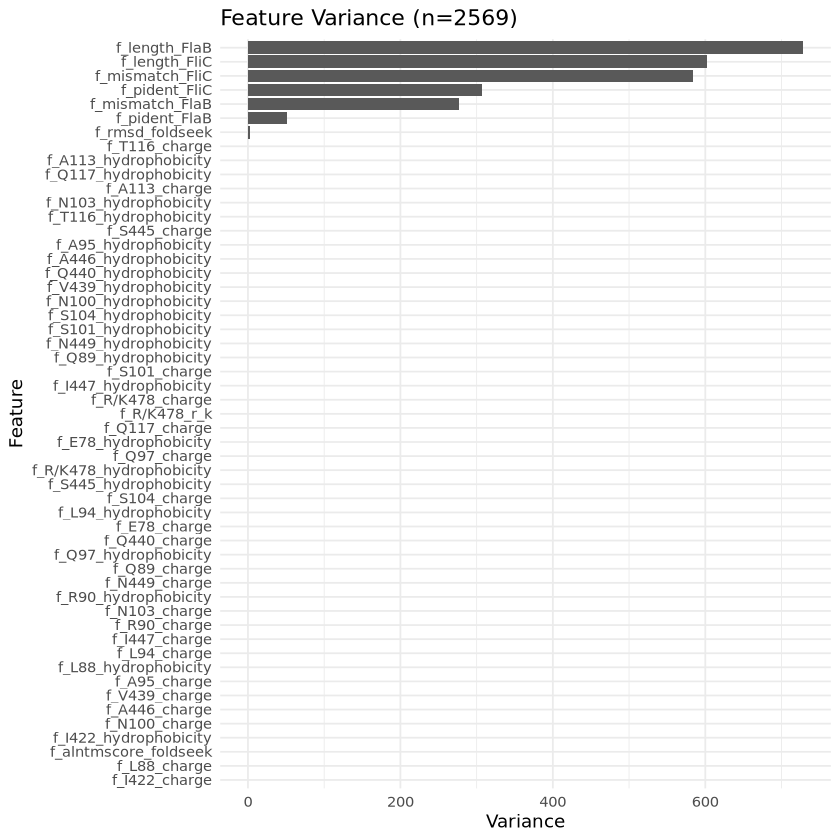

In [54]:
## III.4 Assess feature variance on full dataset (for documentation)

var_report_file <- file.path(work_dir, 'out/annotation/functional/feature_variance_report_31-01-25.tsv')
var_report <- assess_feature_variance(all_features_final,
                                      output_file = var_report_file,
                                      plot = TRUE)

In [55]:
## III.5 Handle missing values

all_features_no_na <- handle_missing_values(all_features_final)

Samples with NAs: 107 

Features with NAs:
           f_R/K478_r_k            f_E78_charge            f_L88_charge 
                     17                      29                      19 
           f_Q89_charge            f_R90_charge            f_L94_charge 
                     19                      19                       9 
           f_A95_charge            f_Q97_charge           f_N100_charge 
                      9                      10                      12 
          f_S101_charge           f_N103_charge           f_S104_charge 
                     11                       7                      12 
          f_A113_charge           f_T116_charge           f_Q117_charge 
                      5                       5                       5 
          f_N449_charge         f_R/K478_charge    f_E78_hydrophobicity 
                      1                      17                      29 
   f_L88_hydrophobicity    f_Q89_hydrophobicity    f_R90_hydrophobicity 
        

In [56]:
## III.6 Save output file

output_file_no_na <- file.path('../../data/model_in/parameters_for_model_curated_2569_no_na_31-01-25.tsv')

metadata_cols <- c('Protein_ID', 'Cluster_CDHit', 'sequence',
                   'Exp.phenotype', 'avg.activity', 'avg.binding')

all_features_no_na <- save_feature_table(all_features_no_na,
                                         output_file_no_na,
                                         metadata_cols)


=== FILE SAVED ===
Output file: ../../data/model_in/parameters_for_model_curated_2569_no_na_31-01-25.tsv 

=== SUMMARY ===
  Samples: 2462 
  Features: 53 
  Metadata columns: 5 
  Total columns: 58 


In [57]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Debian GNU/Linux 13 (trixie)

Matrix products: default
BLAS/LAPACK: /tmp/global2/abogdanova/envs/R/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: MET
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] LeyLabRMisc_0.2.1   ggmsa_1.0.2         Biostrings_2.74.0  
 [4] GenomeInfoDb_1.42.0 XVector_0.46.0      IRanges_2.40.0     
 [7] S4Vectors_0.44.0    BiocGenerics_0.52.0 lubridate_1.9.4    
[10] forcats_1.0.1       stri